# 4장. pandas로 데이터에 질문하기

이 노트북은 데이터를 선택·필터링·정렬하고, 안전하게 병합한 뒤 완료 주문 기준 요약표를 만드는 실습 자료입니다.


## 학습 목표

- 실제 컬럼명과 값의 종류를 확인한 뒤 필터링합니다.
- 수량과 단가로 주문 상세 금액을 계산합니다.
- `validate`와 `indicator`를 사용해 병합 결과를 검증합니다.
- 취소·환불 주문을 제외하고 완료 주문 기준 매출을 계산합니다.
- 개인정보를 최소화한 분석 결과를 저장합니다.


## 0. 제출 정보
- 이름: 진민승
- GitHub ID: Jinminseung
- 작성일: 2026.10.05
- 최종 제출 URL: https://github.com/Jinminseung/llm-data-analysis-study/blob/main/chapter04.ipynb

## 1. 프로젝트 루트와 실행 환경 확인

VS Code에서 Notebook을 실행하면 현재 작업 폴더가 프로젝트 루트 또는 `notebooks` 폴더일 수 있습니다. 아래 코드는 상위 폴더를 확인해 프로젝트 루트를 찾습니다.


In [4]:
from pathlib import Path
import sys

import pandas as pd


def find_project_root(start_path):
    start_path = Path(start_path).resolve()
    for candidate in [start_path, *start_path.parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'scripts').exists():
            return candidate
    raise FileNotFoundError('프로젝트 루트 폴더를 찾을 수 없습니다.')


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
REPORT_DIR = PROJECT_ROOT / 'reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print('Python 실행 파일:', sys.executable)
print('현재 작업 폴더:', Path.cwd())
print('프로젝트 루트:', PROJECT_ROOT)
print('데이터 폴더:', DATA_DIR)
print('결과 저장 폴더:', REPORT_DIR)


Python 실행 파일: c:\Users\rhrnf\llm-data-analysis-study\.venv\Scripts\python.exe
현재 작업 폴더: c:\Users\rhrnf\llm-data-analysis-study\chapter\chapter4
프로젝트 루트: C:\Users\rhrnf\llm-data-analysis-study
데이터 폴더: C:\Users\rhrnf\llm-data-analysis-study\data\raw
결과 저장 폴더: C:\Users\rhrnf\llm-data-analysis-study\reports


## 2. 데이터 파일 확인과 불러오기

파일이 없다면 프로젝트 루트에서 `python scripts/generate_sample_data.py`를 먼저 실행하세요.


In [5]:
required_files = ['customers.csv', 'products.csv', 'orders.csv', 'order_items.csv']
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]

if missing_files:
    raise FileNotFoundError(
        '필요한 데이터 파일이 없습니다: ' + ', '.join(missing_files)
        + '. 프로젝트 루트에서 python scripts/generate_sample_data.py를 실행하세요.'
    )

customers = pd.read_csv(DATA_DIR / 'customers.csv')
products = pd.read_csv(DATA_DIR / 'products.csv')
orders = pd.read_csv(DATA_DIR / 'orders.csv')
order_items = pd.read_csv(DATA_DIR / 'order_items.csv')

print('데이터 불러오기 완료')


데이터 불러오기 완료


## 3. 데이터 구조와 필수 컬럼 확인

LLM이 작성한 코드가 실제 컬럼명과 일치하는지 먼저 확인합니다.


In [6]:
datasets = {
    'customers': customers,
    'products': products,
    'orders': orders,
    'order_items': order_items,
}

expected_columns = {
    'customers': ['customer_id', 'gender', 'age', 'city'],
    'products': ['product_id', 'product_name', 'category', 'price'],
    'orders': ['order_id', 'customer_id', 'order_date', 'order_status'],
    'order_items': ['order_id', 'product_id', 'quantity', 'unit_price'],
}

for name, df in datasets.items():
    missing = [col for col in expected_columns[name] if col not in df.columns]
    print(name, df.shape, df.columns.tolist())
    if missing:
        raise KeyError(f'{name}에 필요한 컬럼이 없습니다: {missing}')


customers (150, 6) ['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']
products (100, 4) ['product_id', 'product_name', 'category', 'price']
orders (300, 5) ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']
order_items (764, 5) ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']


## 4. 컬럼 선택과 행 필터링

이 저장소의 샘플 데이터는 도시명을 `서울`, `부산`처럼 한글로 생성합니다. 필터링 전에 실제 값을 확인합니다.


In [7]:
customer_basic = customers[['customer_id', 'gender', 'age', 'city']]
display(customer_basic.head())

print('도시별 고객 수')
display(customers['city'].value_counts())

customers_over_30 = customers[customers['age'] >= 30]
seoul_customers = customers[customers['city'] == '서울']
city_customers = customers[customers['city'].isin(['서울', '부산'])]

print('30세 이상 고객 수:', len(customers_over_30))
print('서울 고객 수:', len(seoul_customers))
print('서울 또는 부산 고객 수:', len(city_customers))


,customer_id,gender,age,city
0,1,F,19,광주
1,2,F,32,대구
2,3,F,61,성남
3,4,F,55,울산
4,5,F,19,부산


도시별 고객 수


city
성남    21
광주    17
부산    16
대구    15
서울    15
울산    14
인천    14
대전    14
수원    13
고양    11
Name: count, dtype: int64

30세 이상 고객 수: 111
서울 고객 수: 15
서울 또는 부산 고객 수: 31


## 1. 질문과 필요한 데이터 선택
### 내가 확인하려는 질문
고객의 나이대별 주문 비용 총합의 평균은 어떻게 다른가?(주문 상태가 완료인 것들 기준)
### 사용한 파일/컬럼
'customers': ['customer_id', 'age'],
'order_items': ['order_id', 'product_id', 'quantity', 'unit_price'],
'orders': ['order_id', 'customer_id', 'order_status']
### 결과 관찰
고객 나이의 최댓값은 69, 최솟값은 19이므로 10대, 20대, ..., 60대까지 고객 나이를 나누고 주문 비용의 평균을 관찰하고자 하였다. 먼저 연령대별 고객 수를 분석한 결과, 10대 고객 수는 5명이기에 통계적 분석을 하기에는 변동성이 크고 수가 적어 분석 시 유의해야 한다는 점을 알 수 있었다. 나머지 나이대는 최소 20명에서 최대 34명의 고객이 있었다.
### 나의 해석과 판단
19살의 고객을 20대 고객에 합쳐서 사용할 수도 있겠으나, 19살이 만 19살이 아니고 고등학생이라면 성인이 아니기에 합쳤을 경우 20대 고객의 분포를 왜곡할 수 있다. 따라서 따로 분석하는 것이 옳다고 보았다.
### 업무·분석적 의미
가입한 고객 수가 10대 고객 수를 제외하면 40대 고객 수가 가장 적은데, 이런 경우 40대 고객이 왜 다른 연령대에 비해 적은지를 분석하고 40대 고객을 더 가입시키는 홍보 전략을 사용하거나, 반대로 가장 많은 20대 고객에 집중한 홍보 전략을 사용할 수 있다.
### 한계와 추가 확인 사항
연령대별 고객 수를 파악하였고, 이후 병합, 필터링 등을 거쳐 연령대별 평균 주문 금액(총합)을 계산할 예정이다.

In [8]:
customers_age=customers[['customer_id', 'age']].copy()
order_items_=order_items[['order_id', 'product_id', 'quantity', 'unit_price']].copy()
orders_status=orders[['order_id', 'customer_id', 'order_status']].copy()

In [9]:
print(customers_age['age'].min(), customers_age['age'].max())

19 69


In [10]:
for i in range(1, 7):
    customers_age_number = customers_age[(customers_age['age'] >= i * 10) & (customers_age['age'] < (i + 1) * 10)]
    print(f'{i * 10}대 고객 수:', len(customers_age_number))

10대 고객 수: 5
20대 고객 수: 34
30대 고객 수: 33
40대 고객 수: 20
50대 고객 수: 27
60대 고객 수: 31


## 5. 정렬과 주문 상태 확인


In [11]:
display(products.sort_values('price', ascending=False).head(10))
display(customers.sort_values('age', ascending=False).head(10))

print('주문 상태별 건수')
display(orders['order_status'].value_counts())


,product_id,product_name,category,price
98,99,뷰티 상품 099,뷰티,200000
69,70,패션 상품 070,패션,198000
57,58,식품 상품 058,식품,197000
42,43,뷰티 상품 043,뷰티,197000
23,24,스포츠 상품 024,스포츠,196000
8,9,스포츠 상품 009,스포츠,193000
36,37,뷰티 상품 037,뷰티,193000
71,72,뷰티 상품 072,뷰티,189000
7,8,스포츠 상품 008,스포츠,189000
52,53,생활용품 상품 053,생활용품,188000


,customer_id,name,gender,age,city,signup_date
14,15,장정식,M,69,서울,2026-08-08
8,9,송지민,M,69,서울,2025-12-23
54,55,윤영철,M,69,광주,2023-10-04
78,79,이서준,M,69,부산,2023-09-17
136,137,김선영,M,68,울산,2025-02-01
45,46,김서현,M,67,대전,2026-07-17
132,133,김성진,M,67,성남,2026-08-02
123,124,김시우,M,67,대구,2024-11-28
11,12,김정남,F,66,대전,2024-12-04
57,58,김성훈,F,66,성남,2025-08-18


주문 상태별 건수


order_status
completed    184
cancelled     64
refunded      52
Name: count, dtype: int64

## 6. 주문 상세 금액 만들기

`line_total`은 주문 상세 1행의 금액입니다. 주문 상태를 연결하기 전 합계는 확정 매출이 아니라 전체 주문 상세 금액입니다.


In [12]:
order_items = order_items.copy()
order_items['line_total'] = order_items['quantity'] * order_items['unit_price']

all_order_amount = order_items['line_total'].sum()
print('전체 주문 상세 금액:', all_order_amount)
display(order_items[['order_id', 'product_id', 'quantity', 'unit_price', 'line_total']].head())


전체 주문 상세 금액: 255610000


,order_id,product_id,quantity,unit_price,line_total
0,1,100,3,102000,306000
1,1,87,5,25000,125000
2,1,7,3,142000,426000
3,1,9,3,193000,579000
4,2,72,4,189000,756000


## 7. 주문 데이터 병합과 검증

`validate='many_to_one'`은 주문 상세의 동일 주문 ID는 여러 번 나올 수 있지만 주문 테이블의 주문 ID는 한 번만 나와야 한다는 뜻입니다.


In [13]:
print('orders.order_id 중복 수:', orders['order_id'].duplicated().sum())

order_sales = order_items.merge(
    orders[['order_id', 'customer_id', 'order_date', 'order_status']],
    on='order_id',
    how='left',
    validate='many_to_one',
    indicator=True,
)

print('병합 전 행 수:', len(order_items))
print('병합 후 행 수:', len(order_sales))
display(order_sales['_merge'].value_counts())

order_sales = order_sales.drop(columns='_merge')


orders.order_id 중복 수: 0
병합 전 행 수: 764
병합 후 행 수: 764


_merge
both          764
left_only       0
right_only      0
Name: count, dtype: int64

## 8. 완료 주문만 선택하기

이후의 매출 요약은 `order_status == 'completed'`인 주문만 사용합니다.


In [14]:
order_sales['order_date'] = pd.to_datetime(order_sales['order_date'], errors='coerce')
print('날짜 변환 실패:', order_sales['order_date'].isna().sum())

completed_order_sales = order_sales[
    order_sales['order_status'] == 'completed'
].copy()

completed_order_sales['order_month'] = (
    completed_order_sales['order_date'].dt.to_period('M').astype(str)
)

print('전체 주문 상세 행 수:', len(order_sales))
print('완료 주문 상세 행 수:', len(completed_order_sales))
print('완료 주문 매출:', completed_order_sales['line_total'].sum())


날짜 변환 실패: 0
전체 주문 상세 행 수: 764
완료 주문 상세 행 수: 474
완료 주문 매출: 148990000


## 2. 필터링·정렬·파생 컬럼
- 적용한 필터 조건: order_status='completed'인 주문만 사용
- 정렬 기준: 고객의 나이 순(오름차순 정렬)
- 만든 파생 컬럼: line_total
- `line_total` 계산식: line_total=unit_price*quantity

![필터와 파생 컬럼](images/step02_transform.png)
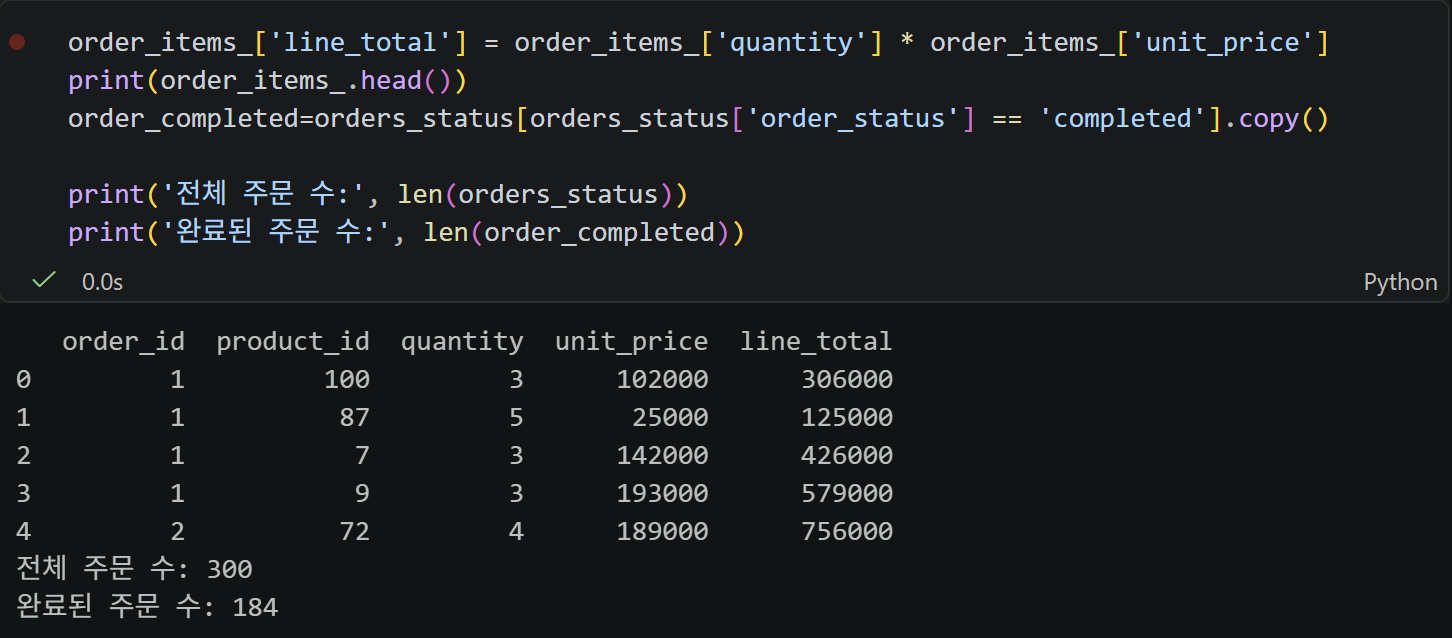
### 결과 관찰
파생 컬럼이 정상적으로 만들어졌고, 고객 데이터프레임도 나이 순으로 정렬이 완료되었다.(오름차순)
### 나의 해석과 판단
만약 필터 기준을 완료된 주문 전체를 선택하는 것이 아닌 주문 날짜나 고객의 다른 정보들을 바탕으로 조건을 추가했다면 주문 수는 현재보다 더 적어졌을 것이다.(물론 내가 선택한 컬럼들만 가지고는 이런 필터링은 힘들다.)
### 업무·분석적 의미
주문별 상세 품목의 총 주문 금액을 파생 컬럼으로 계산했고, 이 주문 금액들을 order_id를 기준으로 합치거나, customer_id를 기준으로 합쳐 주문별 총 주문 금액, 고객별 총 주문 금액을 계산할 수 있을 것이다.
### 한계와 추가 확인 사항
앞서 만들어둔 데이터프레임들을 전부 병합하고, 고객 id 별로 집계하는 과정이 남았다.

In [15]:
order_items_['line_total'] = order_items_['quantity'] * order_items_['unit_price']
print(order_items_.head())
order_completed=orders_status[orders_status['order_status'] == 'completed'].copy()

print('전체 주문 수:', len(orders_status))
print('완료된 주문 수:', len(order_completed))

   order_id  product_id  quantity  unit_price  line_total
0         1         100         3      102000      306000
1         1          87         5       25000      125000
2         1           7         3      142000      426000
3         1           9         3      193000      579000
4         2          72         4      189000      756000
전체 주문 수: 300
완료된 주문 수: 184


In [16]:
customers_age=customers_age.sort_values('age', ascending=True)
customers_age.head()

,customer_id,age
0,1,19
4,5,19
53,54,19
135,136,19
146,147,19


## 9. 상품 데이터 병합과 검증


In [17]:
print('products.product_id 중복 수:', products['product_id'].duplicated().sum())

completed_sales_items = completed_order_sales.merge(
    products,
    on='product_id',
    how='left',
    validate='many_to_one',
    indicator=True,
)

print('병합 전 행 수:', len(completed_order_sales))
print('병합 후 행 수:', len(completed_sales_items))
display(completed_sales_items['_merge'].value_counts())

completed_sales_items = completed_sales_items.drop(columns='_merge')


products.product_id 중복 수: 0
병합 전 행 수: 474
병합 후 행 수: 474


_merge
both          474
left_only       0
right_only      0
Name: count, dtype: int64

## 3. merge 검증
- 병합한 데이터: order_completed, customers_age, order_items_
- 사용한 key: order_completed, order_items_의 병합-order_id
order_sales와 customers_age의 병합-customer_id
- `validate` 결과: 문제없음
- `indicator` 결과: 문제없음
- 병합 전/후 행 수: 최초 병합의 경우 764->474(completed가 아닌 주문이 매칭되지 않음)
이후 병합의 경우 474->474
![merge 검증](images/step03_merge.png)
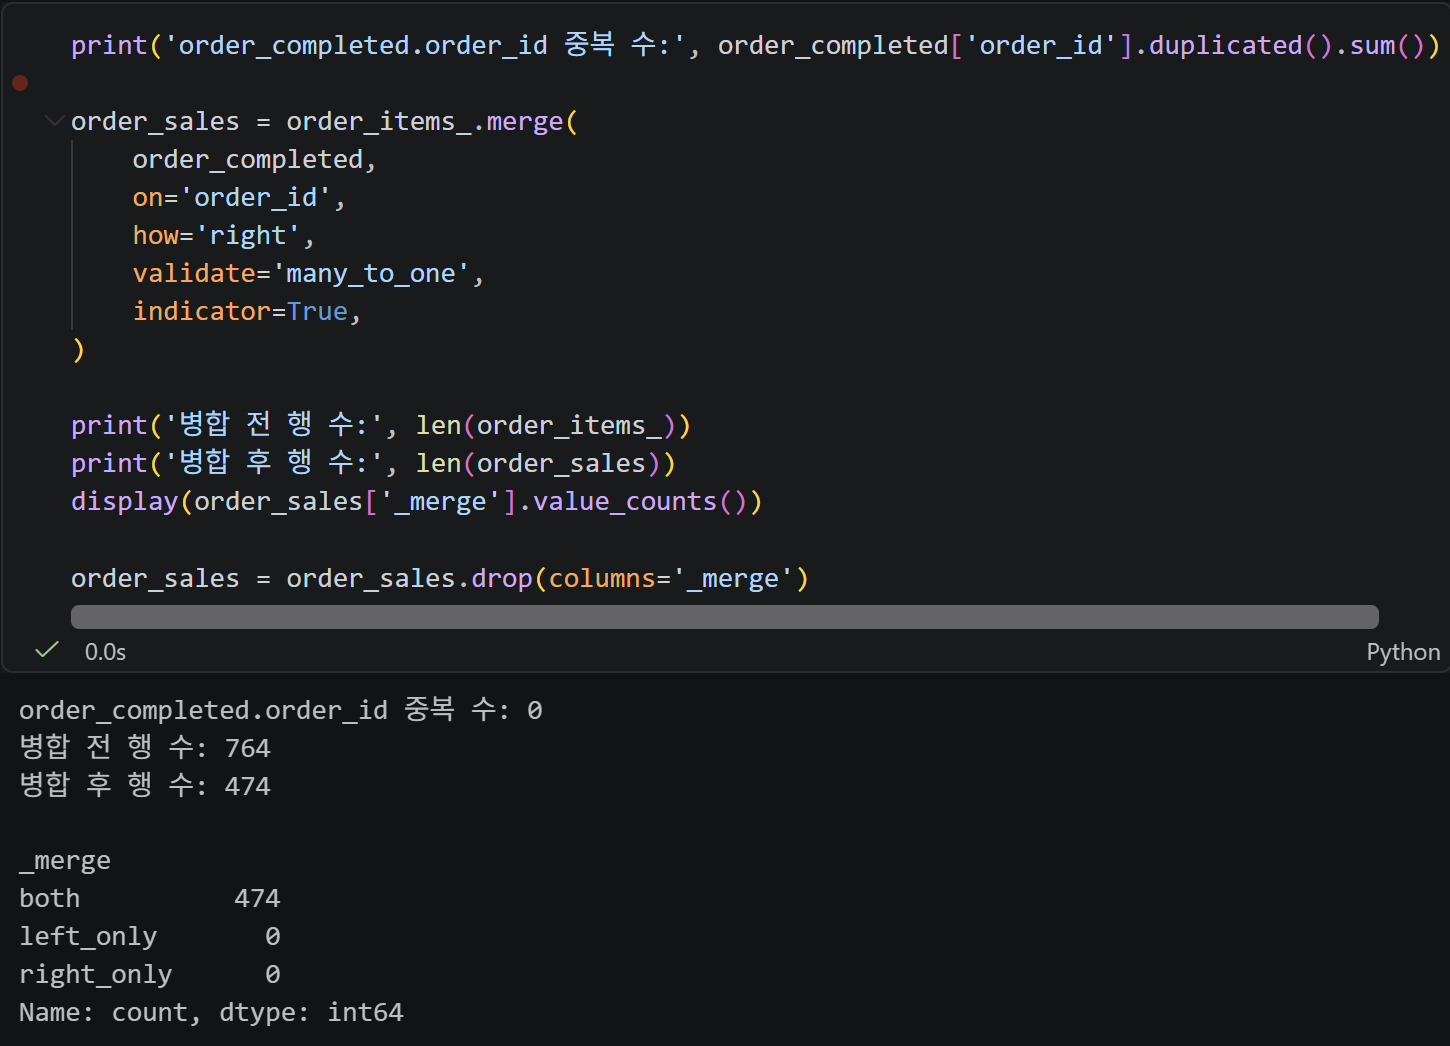
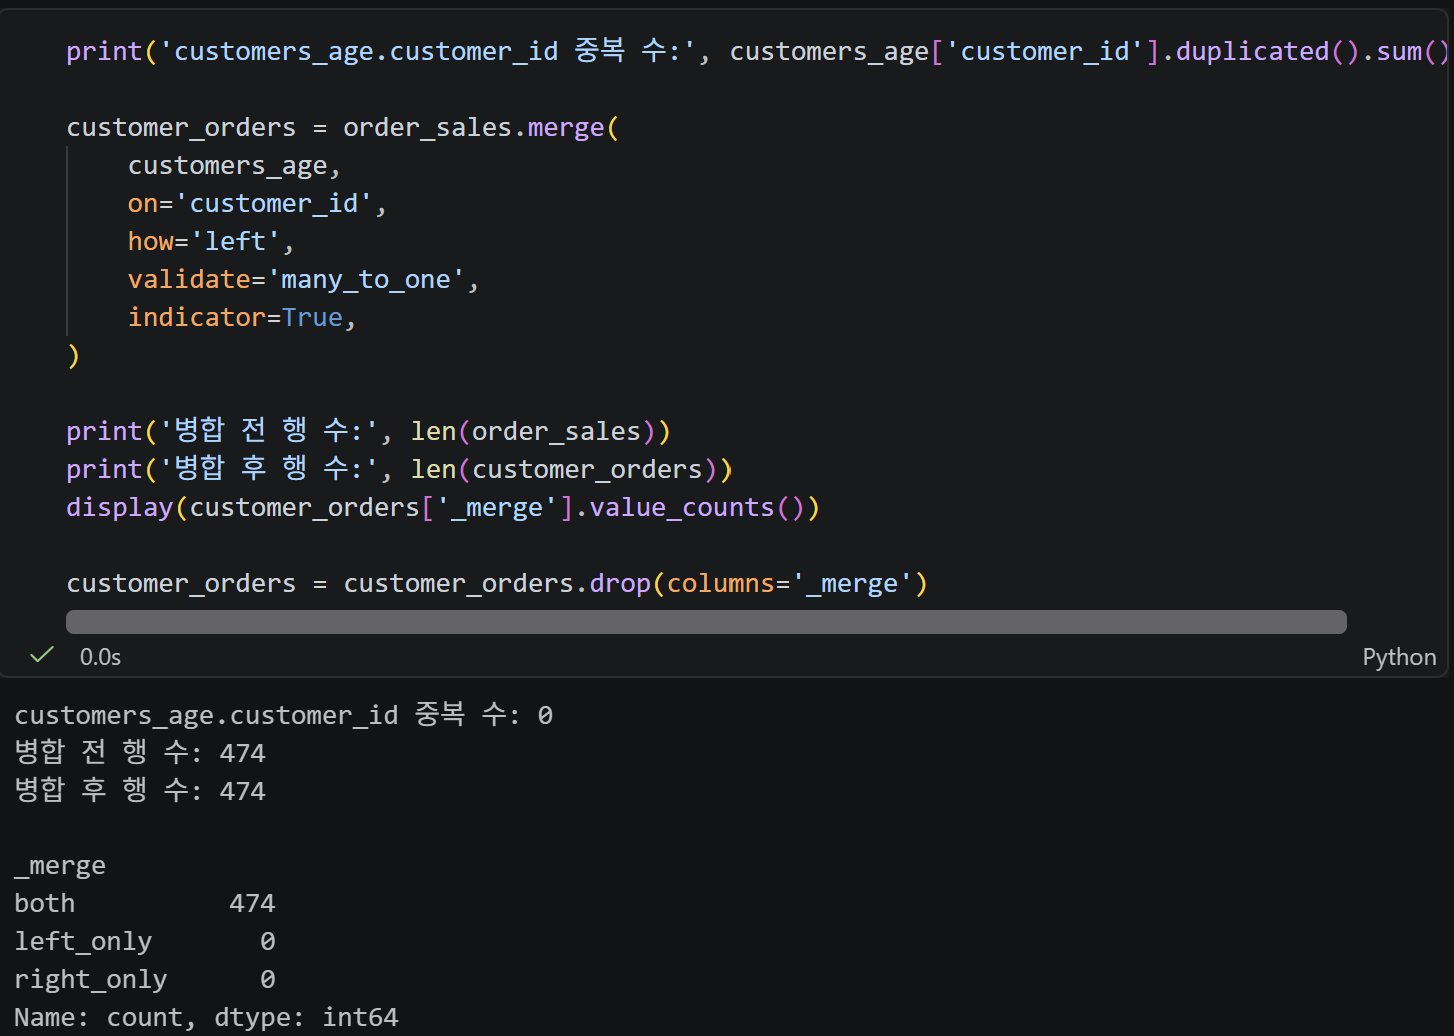
### 결과 관찰
병합은 문제없이 잘 진행되었다.
### 나의 해석과 판단
행 수가 증가하는 것이 아니라면 기본적으로 병합에 문제는 없었다고 볼 수 있다. (둘 모두 many_to_one 매칭이므로) 최초 병합에서는 행 수가 감소했는데, 이는 order_items_에는 필터링을 하지 않아 주문 상태가 완료가 아닌 주문들도 남아있는 반면, order_completed에는 필터링을 해 주문 상태가 완료인 주문만이 남아있기 때문이다.

### 업무·분석적 의미
만약 병합 과정에서 행이 의도치 않게 늘어나면 금액이 중복 집계되어 평균 계산이 잘못될 수 있다. 또, 병합 과정에서 행이 의도치 않게 제거되어 분석에 사용되지 못할 수도 있다.

### 한계와 추가 확인 사항
병합을 완료하였으므로 고객별 주문 금액 집계와 이후 연령대별 평균 총 주문 금액 계산이 남았다.

In [18]:
print('order_completed.order_id 중복 수:', order_completed['order_id'].duplicated().sum())

order_sales = order_items_.merge(
    order_completed,
    on='order_id',
    how='right',
    validate='many_to_one',
    indicator=True,
)

print('병합 전 행 수:', len(order_items_))
print('병합 후 행 수:', len(order_sales))
display(order_sales['_merge'].value_counts())

order_sales = order_sales.drop(columns='_merge')

order_completed.order_id 중복 수: 0
병합 전 행 수: 764
병합 후 행 수: 474


_merge
both          474
left_only       0
right_only      0
Name: count, dtype: int64

In [19]:
print('customers_age.customer_id 중복 수:', customers_age['customer_id'].duplicated().sum())

customer_orders = order_sales.merge(
    customers_age,
    on='customer_id',
    how='left',
    validate='many_to_one',
    indicator=True,
)

print('병합 전 행 수:', len(order_sales))
print('병합 후 행 수:', len(customer_orders))
display(customer_orders['_merge'].value_counts())

customer_orders = customer_orders.drop(columns='_merge')

customers_age.customer_id 중복 수: 0
병합 전 행 수: 474
병합 후 행 수: 474


_merge
both          474
left_only       0
right_only      0
Name: count, dtype: int64

## 10. 카테고리별·상품별 매출


In [20]:
category_sales = (
    completed_sales_items
    .groupby('category', as_index=False)
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('line_total', 'sum'),
    )
    .sort_values('total_sales', ascending=False)
)

category_sales['sales_ratio'] = (
    category_sales['total_sales'] / category_sales['total_sales'].sum() * 100
).round(2)

display(category_sales)

product_sales = (
    completed_sales_items
    .groupby(['product_id', 'product_name', 'category'], as_index=False)
    .agg(
        total_quantity=('quantity', 'sum'),
        total_sales=('line_total', 'sum'),
    )
    .sort_values('total_sales', ascending=False)
)

display(product_sales.head(10))


,category,total_quantity,total_sales,sales_ratio
3,스포츠,295,31743000,21.31
5,전자기기,259,26400000,17.72
2,생활용품,272,23915000,16.05
1,뷰티,223,23383000,15.69
4,식품,133,16573000,11.12
0,도서,149,16389000,11.00
6,패션,111,10587000,7.11


,product_id,product_name,category,total_quantity,total_sales
39,41,스포츠 상품 041,스포츠,35,5705000
11,12,식품 상품 012,식품,25,4375000
8,9,스포츠 상품 009,스포츠,20,3860000
70,72,뷰티 상품 072,뷰티,20,3780000
69,71,전자기기 상품 071,전자기기,23,3703000
66,68,스포츠 상품 068,스포츠,26,3640000
78,81,전자기기 상품 081,전자기기,22,3630000
10,11,패션 상품 011,패션,31,3565000
20,22,생활용품 상품 022,생활용품,29,3248000
86,89,생활용품 상품 089,생활용품,30,3090000


## 11. 월별 매출


In [21]:
monthly_summary = (
    completed_order_sales
    .groupby('order_month', as_index=False)
    .agg(
        total_sales=('line_total', 'sum'),
        order_count=('order_id', 'nunique'),
    )
    .sort_values('order_month')
)

monthly_summary['average_order_value'] = (
    monthly_summary['total_sales'] / monthly_summary['order_count']
).round(0)

display(monthly_summary)


,order_month,total_sales,order_count,average_order_value
0,2025-09,3565000,6,594167.0
1,2025-10,17925000,20,896250.0
2,2025-11,9151000,11,831909.0
3,2025-12,24278000,25,971120.0
4,2026-01,11339000,15,755933.0
5,2026-02,6939000,9,771000.0
6,2026-03,17700000,23,769565.0
7,2026-04,13250000,20,662500.0
8,2026-05,13135000,14,938214.0
9,2026-06,15713000,20,785650.0


## 12. 고객별 구매 금액

고객 ID로 먼저 집계한 뒤 고객 속성을 붙입니다. 출력에는 실제 이름 대신 익명화된 고객 라벨을 사용합니다.


In [22]:
customer_sales = (
    completed_order_sales
    .groupby('customer_id', as_index=False)
    .agg(
        order_count=('order_id', 'nunique'),
        total_sales=('line_total', 'sum'),
    )
    .sort_values('total_sales', ascending=False)
)

customer_sales = customer_sales.merge(
    customers[['customer_id', 'city']],
    on='customer_id',
    how='left',
    validate='one_to_one',
)

customer_sales['customer_label'] = 'Customer ' + customer_sales['customer_id'].astype(str)
display(customer_sales[['customer_label', 'city', 'order_count', 'total_sales']].head(10))


,customer_label,city,order_count,total_sales
0,Customer 117,성남,5,4100000
1,Customer 102,고양,4,3996000
2,Customer 83,수원,4,3880000
3,Customer 30,서울,5,3590000
4,Customer 40,서울,4,3523000
5,Customer 20,인천,2,3191000
6,Customer 3,성남,2,3178000
7,Customer 111,광주,3,3153000
8,Customer 66,서울,4,3093000
9,Customer 147,부산,2,2990000


## 4. completed 주문 범위와 집계
- 분석 범위 정의: order_status가 completed인 모든 주문(전체 기간)
- 카테고리별 결과: 스포츠 카테고리에서 주문금액 총합이 가장 컸고, 패션 카테고리에서 가장 작았다.
- 상품별 결과: 스포츠 상품 041에서 주문금액 총합이 가장 컸고, 그 뒤로 식품 상품 012, 스포츠 상품 009 순이었다.
- 월별 결과: 2025년 12월에 주문금액 총합과 주문횟수가 가장 컸고, 2026년 8월에 주문금액 총합 및 주문횟수가 가장 작았다. 평균 주문금액은 2026년 9월이 가장 컸다.
- 고객별 결과: 117번 고객의 총 주문금액이 가장 컸고, 그 뒤로 102, 83번 고객의 순이었다.
- 연령대별 결과: 10대에서 30대까지는 연령이 증가할수록 평균 주문금액도 커지나, 40대부터는 연령이 증가할수록 평균 주문금액이 감소한다. 60대의 경우는 다시 평균 주문금액이 증가한다.
![핵심 집계 결과](images/step04_groupby.png)
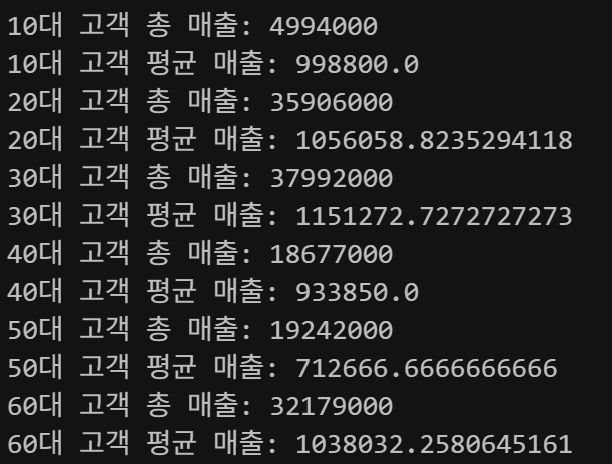
### 결과 관찰
카테고리별 결과를 살펴보면, 스포츠 카테고리에서 주문금액 총합이 가장 컸고, 패션 카테고리에서 가장 작았다. 연령대별 결과를 살펴보면, 10대에서 30대까지는 연령이 증가할수록 평균 주문금액도 커지나, 40대부터는 연령이 증가할수록 평균 주문금액이 감소한다. 그러나 60대의 경우 다시 평균 주문금액이 증가한다.

### 나의 해석과 판단
평균 주문금액이 연령대별로 달라지는데, 10대에서 30대까지는 연령이 증가할수록 평균 주문금액도 커지나, 40대부터는 연령이 증가할수록 평균 주문금액이 감소하나 60대는 다시 평균 주문금액이 증가한다는 사실이 가장 중요해보인다.

### 업무·분석적 의미
10대부터 30대까지는 연령이 증가할수록 평균 주문금액이 증가한다는 사실은, 연령대가 증가할수록 안정된 직장을 가지고 경제력을 갖추는 확률이 높아진다는 것을 의미하며, 이후 연령대가 증가할수록 평균 주문금액이 감소하는 것은 온라인으로 물건을 주문하는 것보다 오프라인 구매가 더 익숙하거나 편할 확률이 높아진다는 것을 의미한다고 볼 수 있다. 60대의 경우 다시 주문금액이 증가하는 현상은 거동이 불편하여 온라인 주문이 오프라인보다 더 편리하기 때문으로 보인다. 따라서 20대~30대와 60대 맞춤형 홍보 전략을 세운다면 매출을 더 늘릴 수 있을 것이다.

### 한계와 추가 확인 사항
현재 total_sales는 completed 주문의 quantity × unit_price 합계이며 할인, 쿠폰 적용, 배송비, 세금, 부분 환불, 원가와 마진을 반영한 회계상 순매출이 아니기 때문이다. 또한 평균 주문금액을 연령대별 총 주문금액/연령대별 고객 수 로 계산하였는데, 이런 경우 주문을 하지 않은 고객도 포함될 수 있다. 주문을 하지 않은 고객을 포함시키는 것과 휴면 고객처럼 판단하는 것 중 무엇이 적합할지는 추가적으로 검증해보아야 한다.


In [33]:
age_customers = {}
for age_group in range(1, 7):
    age_group_customers = customers_age[
        (customers_age['age'] >= age_group * 10) & (customers_age['age'] < (age_group + 1) * 10)
    ]
    age_group_sales = customer_orders[
        customer_orders['customer_id'].isin(age_group_customers['customer_id'])
    ]
    
    total_sales = age_group_sales['line_total'].sum()
    num_customers = len(age_group_customers)
    
    age_customers[f'{age_group * 10}대'] = {
        '고객 수': num_customers,
        '총 매출': total_sales,
        '평균 매출': total_sales / num_customers if num_customers > 0 else 0
    }

age_customers_df = pd.DataFrame.from_dict(age_customers, orient='index')
display(age_customers_df)
   

,고객 수,총 매출,평균 매출
10대,5,4994000,9.988000e+05
20대,34,35906000,1.056059e+06
30대,33,37992000,1.151273e+06
40대,20,18677000,9.338500e+05
50대,27,19242000,7.126667e+05
60대,31,32179000,1.038032e+06


## 5. 총합 일치 검증
- 원본 completed `line_total` 합계: 148990000
- 카테고리 합계: 148990000
- 월별 합계: 148990000
- 고객별 합계: 148990000
- 연령대별 합계: 148990000
- 차이 여부: 없음

![총합 검증](images/step05_total_check.png)
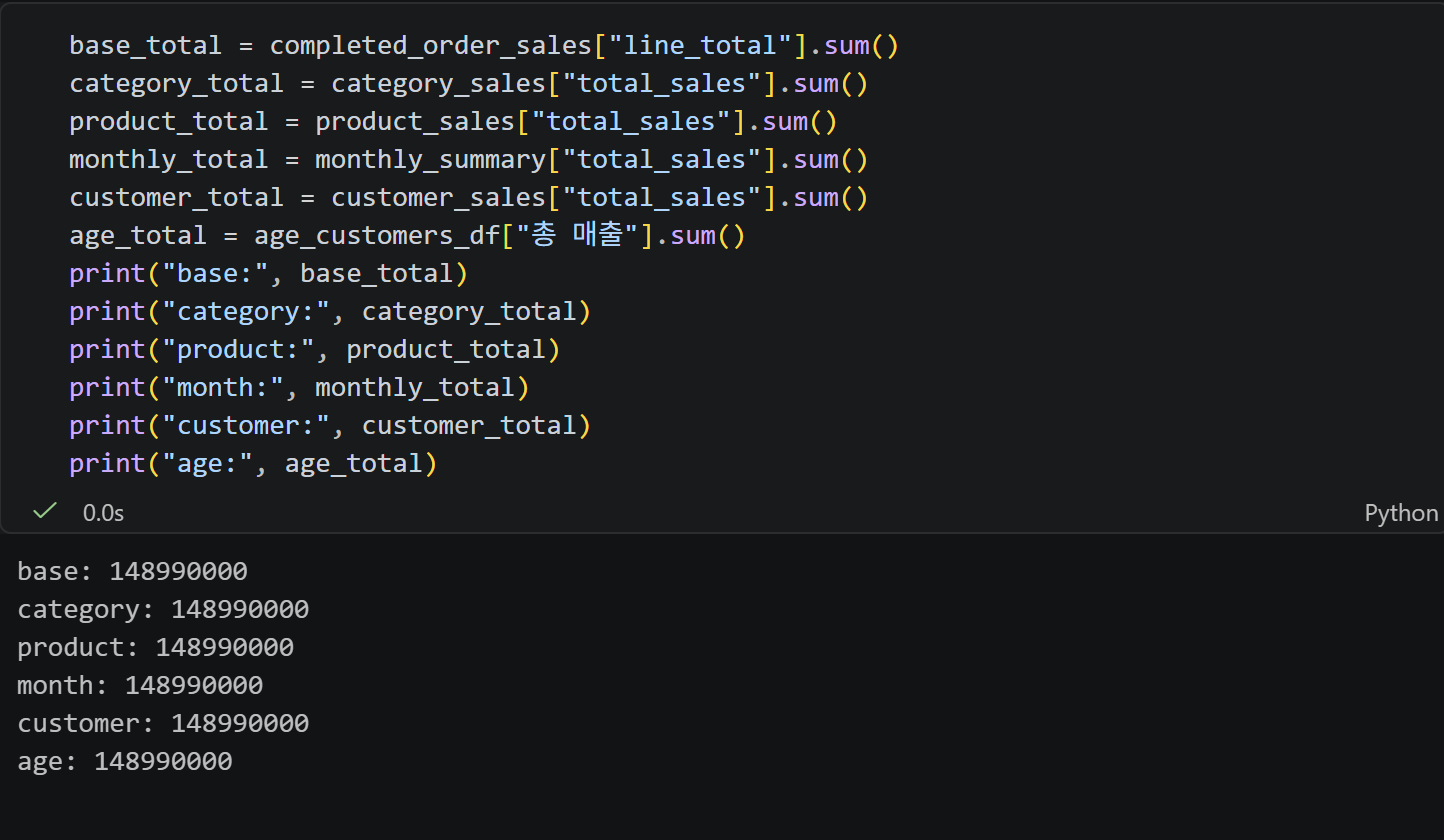
### 나의 해석과 판단
총합 검증이 없다면 중간에 잘못된 코드로 인해 누락되거나 중복 집계된 데이터가 있는지 여부를 확인할 수 없기 때문에 필요하다. 총합 검증 결과 총합이 일치하지 않는다면 필터링이 제대로 되었는지를 먼저 살펴본 후 병합 과정에서 중복이나 누락이 있는지를 확인해야 한다.


In [34]:
base_total = completed_order_sales["line_total"].sum()
category_total = category_sales["total_sales"].sum()
product_total = product_sales["total_sales"].sum()
monthly_total = monthly_summary["total_sales"].sum()
customer_total = customer_sales["total_sales"].sum()
age_total = age_customers_df["총 매출"].sum()
print("base:", base_total)
print("category:", category_total)
print("product:", product_total)
print("month:", monthly_total)
print("customer:", customer_total)
print("age:", age_total)

base: 148990000
category: 148990000
product: 148990000
month: 148990000
customer: 148990000
age: 148990000


## 13. 결과 저장하기


In [32]:
outputs = {
    'ch04_category_sales.csv': category_sales,
    'ch04_product_sales.csv': product_sales,
    'ch04_monthly_sales.csv': monthly_summary,
    'ch04_customer_sales.csv': customer_sales,
    'ch04_age_sales.csv': age_customers_df,
}

for filename, df in outputs.items():
    path = REPORT_DIR / filename
    df.to_csv(path, index=False, encoding='utf-8-sig')
    print(filename, path.exists(), path.stat().st_size)


ch04_category_sales.csv True 254
ch04_product_sales.csv True 4409
ch04_monthly_sales.csv True 442
ch04_customer_sales.csv True 3387
ch04_age_sales.csv True 209


## 14. LLM 코드 검증 연습

```text
LLM이 다음 코드를 제안했습니다.

category_sales = order_items.groupby('category')['line_total'].sum()

현재 데이터에서 이 코드가 바로 실행 가능한지 검토해 주세요.
category 컬럼의 위치, 주문 상태 필터링, merge validate와 indicator를 포함해
안전한 수정 코드와 검증 순서를 설명해 주세요.
```


-order_items에 category 컬럼이 없기에 바로 실행할 수 없다.
-category 컬럼은 products에 있기에 두 데이터프레임을 병합한 후, 주문 상태가 completed인 것들 역시 확인해야 하기에 orders 역시 추가적으로 병합해야 한다.

In [35]:
order_products=order_items.merge(products, on='product_id', how='left', validate='many_to_one', indicator=True)
order_products = order_products.drop(columns='_merge')
order_products_completed=order_products.merge(orders, on='order_id', how='left', validate='many_to_one', indicator=True)
order_products_completed = order_products_completed.drop(columns='_merge')
order_products.head()

,order_item_id,order_id,product_id,quantity,unit_price,line_total,product_name,category,price
0,1,1,100,3,102000,306000,도서 상품 100,도서,102000
1,2,1,87,5,25000,125000,도서 상품 087,도서,25000
2,3,1,7,3,142000,426000,도서 상품 007,도서,142000
3,4,1,9,3,193000,579000,스포츠 상품 009,스포츠,193000
4,5,2,72,4,189000,756000,뷰티 상품 072,뷰티,189000


In [36]:
category_sales=order_products_completed.groupby('category').agg({'line_total': 'sum'}).reset_index()
category_sales = category_sales.sort_values('line_total', ascending=False)
category_sales.head()

,category,line_total
3,스포츠,50174000
1,뷰티,47551000
5,전자기기,41003000
2,생활용품,34839000
4,식품,33597000


## 6. LLM pandas 코드 검증
- LLM Prompt 요약: 연령대별 평균 총 주문금액을 계산하되 데이터프레임과 컬럼명은 모두 제시, 주문 상태 완료인 주문만 포함하고, 병합 과정 자세히, 평균 계산 시 연령대별 총 주문금액을 연령대별 총 고객 수로 나눠서 계산
- 제안 코드 요약: 데이터프레임을 입력받아 병합 과정 및 최종 결과를 도출하는 함수를 코드로 제시
- 실제 컬럼/범위와 맞지 않은 부분: 없음(이미 모든 데이터프레임별 컬럼명을 프롬프트에 제시)
- 수정한 내용: 없음
- 최종 판단: 사용

![LLM 코드 검증](images/step06_llm_validation.png)
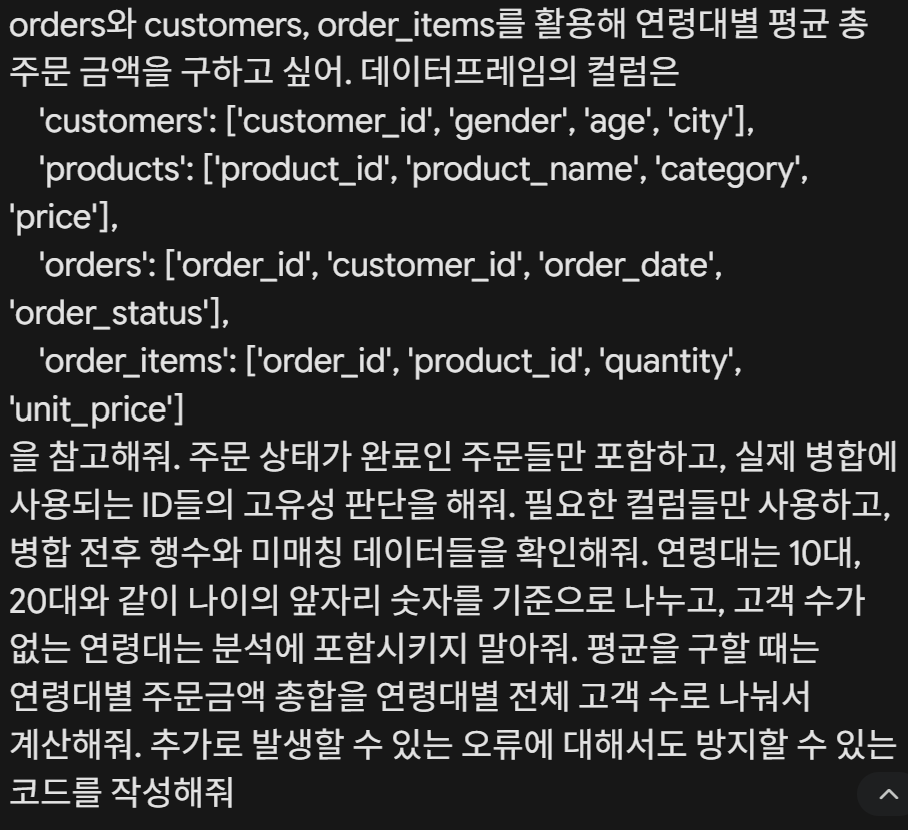
코드는 밑에 추가로 첨부
### 나의 해석과 판단
LLM 코드가 실행되었다는 것만으로 분석이 맞다고는 볼 수 없는데, 필터링을 잘못하거나 병합 과정에서 누락된 데이터가 있거나 하는 등의 문제가 있을 수 있다. 또, 평균 주문 금액을 계산할 때 연령대별 총 고객 수가 아니라 연령대별 주문이 있는 고객 수로 나누는 등 프롬프트 작성자의 의도와 다른 코드를 작성할 수도 있다.

In [37]:
import numpy as np
import pandas as pd


def analyze_avg_order_amount_by_age_group(customers, orders, order_items):
    """customers, orders, order_items 데이터프레임을 활용하여

    연령대별 평균 총 주문 금액을 산출하는 함수
    """

    # -------------------------------------------------------------------------
    # 1. 필요한 컬럼만 추출하여 복사본 생성 (메모리 절약 및 원본 보존)
    # -------------------------------------------------------------------------
    cust_df = customers[["customer_id", "age"]].copy()
    orders_df = orders[["order_id", "customer_id", "order_status"]].copy()
    items_df = order_items[["order_id", "quantity", "unit_price"]].copy()

    # -------------------------------------------------------------------------
    # 2. 예외 방지: 데이터 타입 변환 및 결측치/이상치 처리
    # -------------------------------------------------------------------------
    # 수치형 컬럼 강제 변환 (문자열 등 잘못된 타입 들어오는 예외 방지)
    cust_df["customer_id"] = pd.to_numeric(
        cust_df["customer_id"], errors="coerce"
    )
    cust_df["age"] = pd.to_numeric(cust_df["age"], errors="coerce")

    orders_df["order_id"] = pd.to_numeric(
        orders_df["order_id"], errors="coerce"
    )
    orders_df["customer_id"] = pd.to_numeric(
        orders_df["customer_id"], errors="coerce"
    )

    items_df["order_id"] = pd.to_numeric(items_df["order_id"], errors="coerce")
    items_df["quantity"] = (
        pd.to_numeric(items_df["quantity"], errors="coerce").fillna(0)
    )
    items_df["unit_price"] = (
        pd.to_numeric(items_df["unit_price"], errors="coerce").fillna(0)
    )

    # 필수 키(ID)가 누락되거나 나이가 음수인 데이터 정제
    cust_df = cust_df.dropna(subset=["customer_id", "age"])
    cust_df = cust_df[cust_df["age"] >= 0]
    orders_df = orders_df.dropna(subset=["order_id", "customer_id"])
    items_df = items_df.dropna(subset=["order_id"])

    # -------------------------------------------------------------------------
    # 3. 실제 병합에 사용되는 ID 고유성 판단 및 중복 제거
    # -------------------------------------------------------------------------
    print("=== [1] ID 고유성 검증 ===")
    is_cust_pk_unique = cust_df["customer_id"].is_unique
    is_order_pk_unique = orders_df["order_id"].is_unique

    print(f"- customers.customer_id 고유 여부: {is_cust_pk_unique}")
    print(f"- orders.order_id 고유 여부: {is_order_pk_unique}")

    # PK 고유성이 깨진 경우 안전하게 중복 제거 처리
    if not is_cust_pk_unique:
        print("  [경고] customers 테이블에 중복 customer_id가 존재하여 첫 번째 행만 유지합니다.")
        cust_df = cust_df.drop_duplicates(subset=["customer_id"], keep="first")

    if not is_order_pk_unique:
        print("  [경고] orders 테이블에 중복 order_id가 존재하여 첫 번째 행만 유지합니다.")
        orders_df = orders_df.drop_duplicates(
            subset=["order_id"], keep="first"
        )

    # -------------------------------------------------------------------------
    # 4. 주문 상태 처리 (대소문자/공백 예외 방지) 및 '완료' 주문 필터링
    # -------------------------------------------------------------------------
    orders_df["order_status_clean"] = (
        orders_df["order_status"].astype(str).str.strip().str.lower()
    )
    completed_orders = orders_df[
        orders_df["order_status_clean"] == "completed"
    ].copy()

    print(f"\n전체 주문 수: {len(orders_df)}건 / 완료 주문 수: {len(completed_orders)}건")

    # -------------------------------------------------------------------------
    # 5. 주문 상품별 금액 집계 (quantity * unit_price)
    # -------------------------------------------------------------------------
    items_df["item_total"] = items_df["quantity"] * items_df["unit_price"]
    order_totals = items_df.groupby("order_id", as_index=False)[
        "item_total"
    ].sum()

    # -------------------------------------------------------------------------
    # 6. 병합 전후 행수 및 미매칭 데이터 확인
    # -------------------------------------------------------------------------
    print("\n=== [2] 병합 및 데이터 매칭 검증 ===")

    # (A) 완료된 주문과 주문 상세(order_items) 병합
    rows_completed_before = len(completed_orders)
    merged_orders = pd.merge(
        completed_orders, order_totals, on="order_id", how="left"
    )
    merged_orders["item_total"] = merged_orders["item_total"].fillna(0)

    # 미매칭 확인 1: 주문은 있으나 상세 금액이 없는 경우
    unmatched_orders_count = (merged_orders["item_total"] == 0).sum()
    print(
        f"- 완료 주문 병합 전 행수: {rows_completed_before} -> 병합 후 행수: {len(merged_orders)}"
    )
    print(f"- 품목 상세 정보가 없는 완료 주문 수: {unmatched_orders_count}건")

    # 고객별 완료 주문 총 금액 합산
    cust_order_sum = merged_orders.groupby("customer_id", as_index=False)[
        "item_total"
    ].sum()
    cust_order_sum.rename(
        columns={"item_total": "total_order_amount"}, inplace=True
    )

    # (B) 고객 정보(customers) 기준 주문 금액 병합
    rows_cust_before = len(cust_df)
    cust_merged = pd.merge(
        cust_df, cust_order_sum, on="customer_id", how="left"
    )
    cust_merged["total_order_amount"] = cust_merged[
        "total_order_amount"
    ].fillna(0)

    # 미매칭 확인 2: 완료된 주문 내역이 없는 고객 수
    unmatched_cust_count = (cust_merged["total_order_amount"] == 0).sum()
    print(
        f"- 전체 고객 병합 전 행수: {rows_cust_before} -> 병합 후 행수: {len(cust_merged)}"
    )
    print(f"- 완료된 주문이 없는 고객 수: {unmatched_cust_count}명")

    # -------------------------------------------------------------------------
    # 7. 나이 기준 연령대 그룹화 (앞자리 숫자 기준: 10대, 20대...)
    # -------------------------------------------------------------------------
    cust_merged["age_group"] = (
        (cust_merged["age"].astype(int) // 10 * 10).astype(str) + "대"
    )

    # -------------------------------------------------------------------------
    # 8. 연령대별 집계 및 평균 총 주문 금액 계산
    # -------------------------------------------------------------------------
    result = (
        cust_merged.groupby("age_group")
        .agg(
            total_customers=("customer_id", "count"),  # 연령대별 전체 고객 수
            ordering_customers=(
                "total_order_amount",
                lambda x: (x > 0).sum(),
            ),  # 실제 주문 고객 수
            sum_order_amount=("total_order_amount", "sum"),  # 주문금액 총합
        )
        .reset_index()
    )

    # 고객 수가 0인 연령대 제외 (groupby 결과 기본 필터링 + 추가 검증)
    result = result[result["total_customers"] > 0].copy()

    # 평균 계산: 연령대별 주문금액 총합 / 연령대별 전체 고객 수
    # 0으로 나누는 오류 방지(np.where 활용)
    result["avg_order_amount"] = np.where(
        result["total_customers"] > 0,
        result["sum_order_amount"] / result["total_customers"],
        0,
    )

    # 소수점 둘째 자리 정리
    result["avg_order_amount"] = result["avg_order_amount"].round(2)

    return result

In [38]:
df=analyze_avg_order_amount_by_age_group(customers, orders, order_items)
df

=== [1] ID 고유성 검증 ===
- customers.customer_id 고유 여부: True
- orders.order_id 고유 여부: True

전체 주문 수: 300건 / 완료 주문 수: 184건

=== [2] 병합 및 데이터 매칭 검증 ===
- 완료 주문 병합 전 행수: 184 -> 병합 후 행수: 184
- 품목 상세 정보가 없는 완료 주문 수: 0건
- 전체 고객 병합 전 행수: 150 -> 병합 후 행수: 150
- 완료된 주문이 없는 고객 수: 50명


,age_group,total_customers,ordering_customers,sum_order_amount,avg_order_amount
0,10대,5,2,4994000.0,998800.00
1,20대,34,23,35906000.0,1056058.82
2,30대,33,25,37992000.0,1151272.73
3,40대,20,14,18677000.0,933850.00
4,50대,27,14,19242000.0,712666.67
5,60대,31,22,32179000.0,1038032.26


## 15. 실습 과제

1. 40세 이상 고객을 추출합니다.
2. 상품 가격이 낮은 순서대로 10개를 출력합니다.
3. 결제수단별 주문 수와 비율을 계산합니다.
4. 카테고리별 평균 상품 가격을 계산합니다.
5. 완료 주문과 전체 주문의 금액 차이를 계산합니다.
6. 병합 검증을 포함한 고객별 구매 금액 코드 요청 프롬프트를 작성합니다.


In [39]:
# 실습과제 1
customers_age_over_40=customers_age[customers_age['age'] >= 40]
customers_age_over_40.head()

,customer_id,age
130,131,40
140,141,40
109,110,40
149,150,40
13,14,40


In [41]:
# 실습과제 2
products.sort_values('price', ascending=True).head(10)

,product_id,product_name,category,price
5,6,전자기기 상품 006,전자기기,5000
27,28,뷰티 상품 028,뷰티,5000
97,98,스포츠 상품 098,스포츠,10000
46,47,생활용품 상품 047,생활용품,11000
94,95,전자기기 상품 095,전자기기,20000
49,50,뷰티 상품 050,뷰티,23000
82,83,전자기기 상품 083,전자기기,24000
86,87,도서 상품 087,도서,25000
41,42,패션 상품 042,패션,28000
58,59,뷰티 상품 059,뷰티,32000


In [42]:
# 실습과제 3
order_counts=orders['payment_method'].value_counts()
print(order_counts)
print(order_counts / order_counts.sum() * 100)

payment_method
kakao_pay        79
naver_pay        77
bank_transfer    74
card             70
Name: count, dtype: int64
payment_method
kakao_pay        26.333333
naver_pay        25.666667
bank_transfer    24.666667
card             23.333333
Name: count, dtype: float64


In [ ]:
# 실습과제 4
products.groupby('category')['price'].mean().sort_values(ascending=False)

category
식품      137142.857143
뷰티      117687.500000
패션      115909.090909
스포츠     111578.947368
도서      106857.142857
전자기기    101588.235294
생활용품     96437.500000
Name: price, dtype: float64

In [45]:
# 실습과제 5
order_completed=orders[orders['order_status'] == 'completed'].copy()
order_items_completed=order_completed.merge(order_items, on='order_id', how='left', validate='one_to_many', indicator=True)
order_items_completed = order_items_completed.drop(columns='_merge')
order_items_total=orders.merge(order_items, on='order_id', how='left', validate='one_to_many', indicator=True)
order_items_total = order_items_total.drop(columns='_merge')
print(f'총 주문금액 : {order_items_total["line_total"].sum()}')
print(f'완료 주문금액 : {order_items_completed["line_total"].sum()}')

총 주문금액 : 255610000
완료 주문금액 : 148990000


In [47]:
# 실습과제 6
# 고객별 금액 구매 금액을 계산하는 코드를 만들어줘. 필요한 컬럼만 사용해줘. 전체 데이터 및 컬럼은 아래와 같아.
#'customers': ['customer_id', 'gender', 'age', 'city']
#'products': ['product_id', 'product_name', 'category', 'price']
#'orders': ['order_id', 'customer_id', 'order_date', 'order_status'],
#'order_items': ['order_id', 'product_id', 'quantity', 'unit_price']
#병합 검증 및 미확인 데이터 여부 역시 확인해줘.

## 정리

이번 장에서는 실제 값 확인, 컬럼 선택, 필터링, 정렬, 파생 컬럼, 병합 검증, 완료 주문 기준 집계, CSV 저장 과정을 수행했습니다. 다음 장에서는 결측치, 중복, 타입 오류, 날짜 형식, 이상값 후보를 다루는 데이터 전처리로 이어집니다.


## 7. Chapter 04 최종 인사이트
### 가장 의미 있다고 생각한 결과 2가지
1. 연령대별 평균 주문 금액은 10대에서 30대까지 증가하고, 30대에서 50대까지 감소한다.
2. 60대에서의 평균 주문 금액은 2번째로 높다.

### 그 결과를 뒷받침하는 수치/표
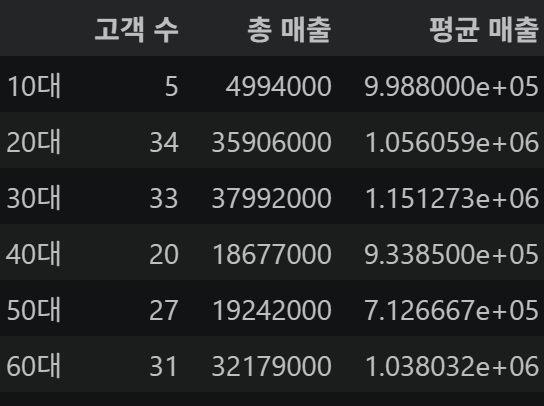
### 추가로 확인하고 싶은 질문
연령대별 평균 주문 금액 외에 연령대별 주문이 있는 고객의 비율과, 완료된 주문이 있는 고객의 비율 역시 추가로 계산하여 해당 연령대가 매출에 얼마나 도움이 되는지를 확인해보고 싶다.
### 현재 결과의 한계
현재 평균 주문 금액을 그대로 매출로 볼 수는 없다. 쿠폰 적용, 할인 및 특가, 배송비 등의 사항이 고려되지 않고 순수하게 개당 가격과 물건 개수 만을 곱한 line_total을 기준으로 계산했기 때문이다.
## 최종 제출 체크
- [V] 핵심 셀 Output이 남아 있습니다.
- [V] merge와 총합 검증 Evidence가 있습니다.
- [V] 결과 관찰과 해석이 구분되어 있습니다.
- [V] LLM 코드를 검증했습니다.
- [V] 개인정보/Secret이 없습니다.
- [V] `chapter04/chapter04.ipynb`가 GitHub에서 정상 표시됩니다.
- [V] 최종 Notebook 파일 URL을 제출합니다.